# Zadanie 1: Optymalizacja gradientowa

**Autor:** Bartłomiej Mazgaj 
**Data:** 16 marca 2026

---

## Wybrana funkcja testowa: Himmelblau

Funkcja Himmelblaua (ang. *Himmelblau's function*) to klasyczna 2-wymiarowa funkcja testowa do optymalizacji:

$$f(x_1, x_2) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$$

**Dziedzina przeszukiwania:** $x_1, x_2 \in [-5, 5]$

Funkcja posiada **cztery globalne minima** (wszystkie z wartością $f = 0$), zgodnie z artykułem Wikipedii ([Test functions for optimization](https://en.wikipedia.org/wiki/Test_functions_for_optimization)):

| Minimum | $x_1$ | $x_2$ | $f(x_1, x_2)$ |
|:-------:|:------:|:------:|:--------------:|
| 1 | $3{,}0$ | $2{,}0$ | $0$ |
| 2 | $-2{,}805118$ | $3{,}131312$ | $0$ |
| 3 | $-3{,}779310$ | $-3{,}283186$ | $0$ |
| 4 | $3{,}584428$ | $-1{,}848126$ | $0$ |

**Gradient analityczny:**

$$\frac{\partial f}{\partial x_1} = 4x_1(x_1^2 + x_2 - 11) + 2(x_1 + x_2^2 - 7)$$

$$\frac{\partial f}{\partial x_2} = 2(x_1^2 + x_2 - 11) + 4x_2(x_1 + x_2^2 - 7)$$

---

## Plan eksperymentu

| Zadanie | Metoda | Cel |
|:-------:|:------:|:---:|
| 3.0 | Gradient descent, stały krok $\alpha$ | Zbieżność wolna / szybka / rozbieżna |
| 4.0 | Armijo line search, bracket $[0,1]$ | Porównanie 6 zestawów `(β, p)` |
| 5.0 | Armijo z automatycznym bracketingiem | Porównanie 6 zestawów `(β, p, α0, γ)` |

We wszystkich eksperymentach:
- punkt reprezentowany jako `Vector{Float64}`,
- funkcja przyjmuje wektor i zwraca skalar,
- gradient jest wektorem tego samego wymiaru co punkt,
- ziarnistość generatora: `Random.seed!(2026)` (odtwarzalność wyników).

In [1]:
using LinearAlgebra
using Plots
using Random
using Statistics

gr()
default(fmt = :png)

# ── Funkcja Himmelblaua i jej gradient analityczny ──────────────────────────
function himmelblau(x::AbstractVector{<:Real})
    @assert length(x) == 2
    x1, x2 = x
    return (x1^2 + x2 - 11)^2 + (x1 + x2^2 - 7)^2
end

function grad_himmelblau(x::AbstractVector{<:Real})
    @assert length(x) == 2
    x1, x2 = x
    g1 = 4 * x1 * (x1^2 + x2 - 11) + 2 * (x1 + x2^2 - 7)
    g2 = 2 * (x1^2 + x2 - 11) + 4 * x2 * (x1 + x2^2 - 7)
    return [g1, g2]
end

# Znane globalne minima (Wikipedia)
global_minima = [
    [3.0,       2.0      ],
    [-2.805118, 3.131312 ],
    [-3.779310, -3.283186],
    [3.584428,  -1.848126],
]

println("Weryfikacja minimów globalnych Himmelblaua:")
for (i, m) in enumerate(global_minima)
    println("  Minimum $i: x = ", round.(m, digits=6),
            "  f(x) = ", round(himmelblau(m), digits=10))
end

# ── Dziedzina i losowanie punktów startowych ────────────────────────────────
domain_lower = [-5.0, -5.0]
domain_upper = [ 5.0,  5.0]

function random_point(lower, upper)
    return [rand() * (upper[i] - lower[i]) + lower[i] for i in eachindex(lower)]
end

Random.seed!(2026)
start_points = [random_point(domain_lower, domain_upper) for _ in 1:10]

println("\nWylosowane punkty startowe (10):")
for (i, p) in enumerate(start_points)
    println("  $i: ", round.(p, digits=4), "  f = ", round(himmelblau(p), digits=3))
end

Weryfikacja minimów globalnych Himmelblaua:
  Minimum 1: x = [3.0, 2.0]  f(x) = 0.0
  Minimum 2: x = [-2.805118, 3.131312]  f(x) = 0.0
  Minimum 3: x = [-3.77931, -3.283186]  f(x) = 0.0
  Minimum 4: x = [3.584428, -1.848126]  f(x) = 0.0

Wylosowane punkty startowe (10):
  1: [1.1309, -2.014]  f = 140.999
  2: [0.4691, 0.9928]  f = 126.539
  3: [-3.7056, -1.8503]  f = 53.802
  4: [1.8495, 3.9898]  f = 128.838
  5: [-1.1216, 3.5968]  f = 60.951
  6: [-2.1657, 3.7558]  f = 30.931
  7: [2.054, -4.5357]  f = 372.268
  8: [4.2303, -3.5243]  f = 104.502
  9: [-2.7792, -2.4919]  f = 46.009
  10: [0.772, 3.3115]  f = 72.753


## Zadanie 3.0 – Metoda największego spadku ze stałym krokiem

Uruchamiamy 100 kroków metody gradientowej dla każdego z 10 wylosowanych punktów startowych.
Testujemy trzy wartości kroku:

| Krok $\alpha$ | Oczekiwane zachowanie |
|:---:|:---|
| `0.001` | Wolna zbieżność (małe kroki, powolny spadek) |
| `0.01` | Szybka zbieżność (dobry dobór kroku) |
| `0.05` | Brak zbieżności / rozbieżność (krok za duży, oscylacje lub eksplozja) |

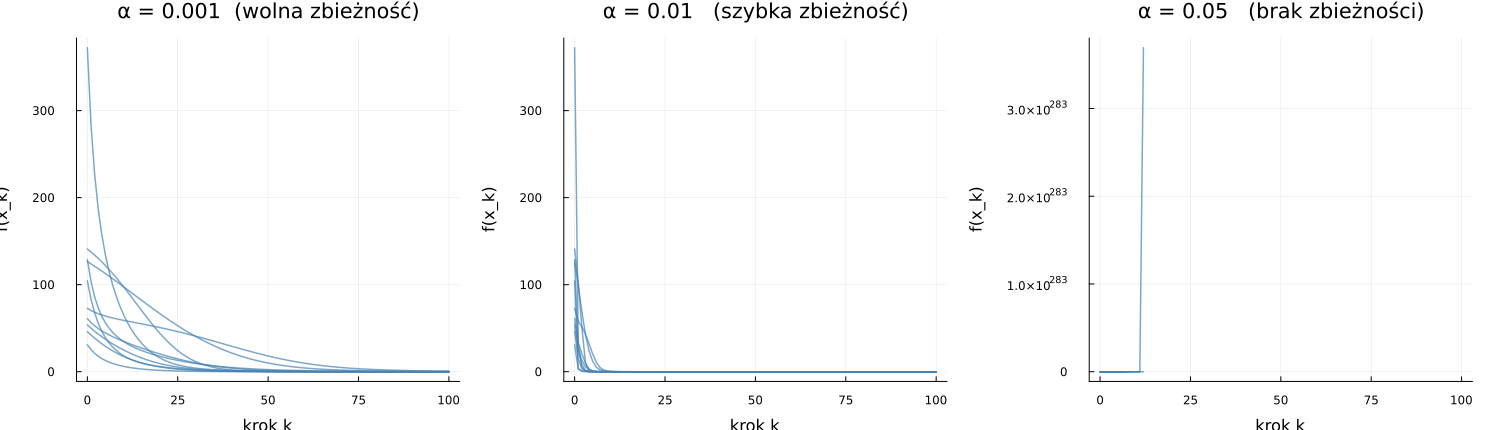

Średnia f̄(100) po 10 punktach startowych:
  α = 0.001:  f̄(100) = 0.105876
  α = 0.01:  f̄(100) = 0.0
  α = 0.05:  f̄(100) = NaN


In [2]:
# ── Narzędzia pomocnicze ────────────────────────────────────────────────────
function mean_finite(values::AbstractVector{<:Real})
    filtered = filter(isfinite, values)
    return isempty(filtered) ? NaN : mean(filtered)
end

function average_curves(curves::Vector{Vector{Float64}})
    n = length(curves[1])
    return [mean_finite([c[k] for c in curves]) for k in 1:n]
end

# ── Metoda największego spadku – stały krok ─────────────────────────────────
function gradient_descent_fixed(f, grad_f, x0; alpha=0.01, steps=100)
    x = Float64.(x0)
    values = Vector{Float64}(undef, steps + 1)
    values[1] = f(x)
    for k in 1:steps
        x = x - alpha * grad_f(x)
        fx = f(x)
        values[k + 1] = fx
        if !isfinite(fx)
            values[(k + 2):end] .= NaN
            break
        end
    end
    return values
end

steps = 100
fixed_alphas = [0.001, 0.01, 0.05]

results_fixed = Dict{Float64, Vector{Vector{Float64}}}()
for alpha in fixed_alphas
    results_fixed[alpha] = [
        gradient_descent_fixed(himmelblau, grad_himmelblau, p;
                               alpha=alpha, steps=steps)
        for p in start_points
    ]
end

p3 = plot(layout=(1, 3), size=(1500, 430), margin=5Plots.mm)
titles = ["α = 0.001  (wolna zbieżność)",
          "α = 0.01   (szybka zbieżność)",
          "α = 0.05   (brak zbieżności)"]
for (i, alpha) in enumerate(fixed_alphas)
    for curve in results_fixed[alpha]
        plot!(p3[i], 0:steps, curve, lw=1.5, alpha=0.7,
              color=:steelblue, label=false)
    end
    title!(p3[i], titles[i])
    xlabel!(p3[i], "krok k")
    ylabel!(p3[i], "f(x_k)")
end
display(p3)

println("Średnia f̄(100) po 10 punktach startowych:")
for alpha in fixed_alphas
    avg = average_curves(results_fixed[alpha])
    println("  α = $(alpha):  f̄(100) = ", round(avg[end], digits=6))
end

## Zadanie 4.0 – Warunek Armijo z bracketem $[0, 1]$

**Warunek wystarczającego spadku Armijo** (backtracking line search):

$$f(x_k + \alpha_k d_k) \leq f(x_k) + \beta \alpha_k d_k \nabla f(x_k) $$

gdzie:
- $\beta \in (0, 1)$ – parametr warunku wystarczającego spadku,
- $p \in (0, 1)$ – współczynnik redukcji kroku w backtrackingu.

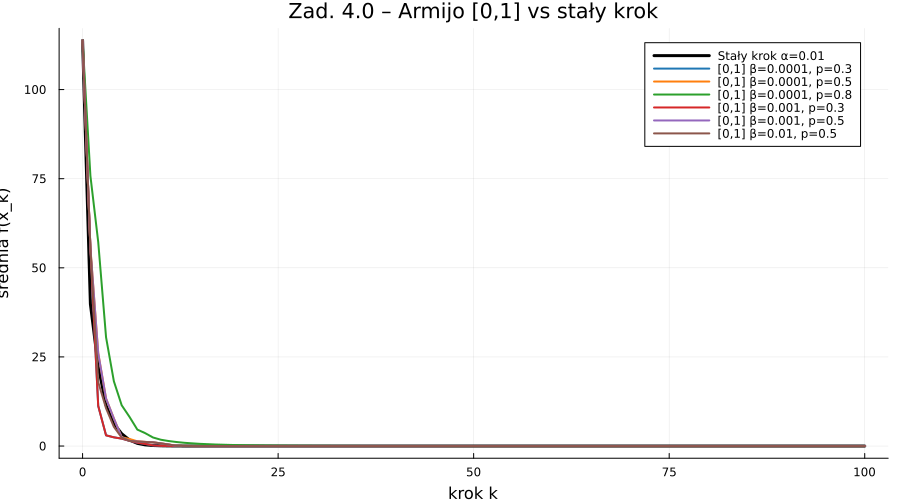

Wyniki końcowe f̄(100):
  Stały krok α=0.01: 0.0
  Armijo [0,1] β=0.0001, p=0.3: 0.0
  Armijo [0,1] β=0.0001, p=0.5: 0.0
  Armijo [0,1] β=0.0001, p=0.8: 2.0e-6
  Armijo [0,1] β=0.001, p=0.3: 0.0
  Armijo [0,1] β=0.001, p=0.5: 0.0
  Armijo [0,1] β=0.01, p=0.5: 0.0


In [3]:
# ── Armijo backtracking – stały bracket [0, 1] ──────────────────────────────
function armijo_fixed_bracket(f, grad_f, x, d; alpha=1.0,
                                  p=0.5, beta=1e-4, alpha_min=1e-12)
    fx  = f(x)
    gtd = dot(grad_f(x), d)
    while alpha >= alpha_min && f(x + alpha * d) > fx + beta * alpha * gtd
        alpha *= p
    end
    return alpha < alpha_min ? alpha_min : alpha
end

function gradient_descent_armijo_fixed(f, grad_f, x0; steps=100, p=0.5, beta=1e-4)
    x = Float64.(x0)
    values = Vector{Float64}(undef, steps + 1)
    values[1] = f(x)
    for k in 1:steps
        d = -grad_f(x)
        alpha = armijo_fixed_bracket(f, grad_f, x, d; p=p, beta=beta)
        x = x + alpha * d
        values[k + 1] = f(x)
    end
    return values
end


baseline_alpha = 0.01
baseline_avg = average_curves(results_fixed[baseline_alpha])

armijo_params = [
    (beta=1e-4, p=0.3),
    (beta=1e-4, p=0.5),
    (beta=1e-4, p=0.8),
    (beta=1e-3, p=0.3),
    (beta=1e-3, p=0.5),
    (beta=1e-2, p=0.5),
]

armijo_fixed_avg = Dict{Tuple{Float64,Float64}, Vector{Float64}}()
for prm in armijo_params
    curves = [gradient_descent_armijo_fixed(himmelblau, grad_himmelblau, p0;
                steps=steps, beta=prm.beta, p=prm.p) for p0 in start_points]
    armijo_fixed_avg[(prm.beta, prm.p)] = average_curves(curves)
end

p4 = plot(0:steps, baseline_avg, lw=3, color=:black,
          label="Stały krok α=$(baseline_alpha)")
palette4 = palette(:tab10)
for (j, prm) in enumerate(armijo_params)
    avg = armijo_fixed_avg[(prm.beta, prm.p)]
    plot!(p4, 0:steps, avg, lw=2, color=palette4[j],
          label="[0,1] β=$(prm.beta), p=$(prm.p)")
end
xlabel!(p4, "krok k")
ylabel!(p4, "średnia f̄(x_k)")
title!(p4, "Zad. 4.0 – Armijo [0,1] vs stały krok")
plot!(p4, size=(900, 500), legend=:topright)
display(p4)

println("Wyniki końcowe f̄(100):")
println("  Stały krok α=$(baseline_alpha): ", round(baseline_avg[end], digits=6))
for prm in armijo_params
    avg = armijo_fixed_avg[(prm.beta, prm.p)]
    println("  Armijo [0,1] β=$(prm.beta), p=$(prm.p): ", round(avg[end], digits=6))
end

## Wnioski

### Zadanie 3.0 – stały krok

- **Mały krok** ($\alpha = 0{,}001$): zbieżność pewna, ale powolna – krzywe wolno malejące przez cały horyzont 100 kroków.
- **Średni krok** ($\alpha = 0{,}01$): szybka zbieżność; dla większości punktów startowych metoda trafia w pobliże jednego z czterech minimów globalnych w kilkudziesięciu krokach.
- **Duży krok** ($\alpha = 0{,}05$): brak zbieżności – gradient mnoży za duży krok, co prowadzi do oscylacji lub rozbieżności (wartości NaN/Inf).

### Zadanie 4.0 – Armijo z bracketem [0, 1]

- Wariant Armijo automatycznie dostosowuje $\alpha$ w każdym kroku, eliminując ryzyko rozbieżności.
- Mniejsze $p$ (np. $0{,}3$) szybciej zmniejsza krok, co zwykle zwiększa stabilność, ale może spowalniać zbieżność.
- Większe $p$ (np. $0{,}8$) utrzymuje duże kroki dłużej – potencjalnie przyspiesza zejście, lecz bywa mniej zachowawcze.
- Parametr $\beta$ (warunek wystarczającego spadku) kontroluje rygor akceptacji kroku: większe wartości wymagają większego spadku funkcji.

